<a href="https://colab.research.google.com/github/Otavio8888/microeconometric/blob/retail_sales_test/varejo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Baixando dados para LREN3.SA...
Baixando dados para MGLU3.SA...

--- Amostra dos Dados Calculados ---
              Ticker       ROA         CCC         PME         PMR         PMP
2021-12-31  LREN3.SA  0.029568  177.067344  131.849525  186.888259  141.670440
2021-12-31  MGLU3.SA  0.015388   45.021702  124.143006   58.464716  137.586021
2022-12-31  LREN3.SA  0.061077  193.356745  126.038896  179.454381  112.136532
2022-12-31  MGLU3.SA -0.013212   42.330604  105.858673   66.154546  129.682616
2023-12-31  LREN3.SA  0.047644  176.477881  119.321322  177.559381  120.402821


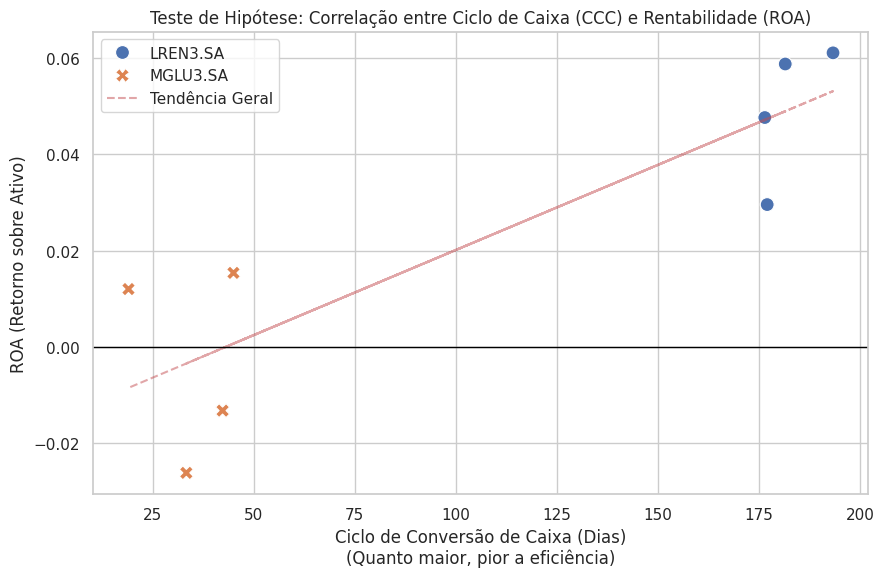

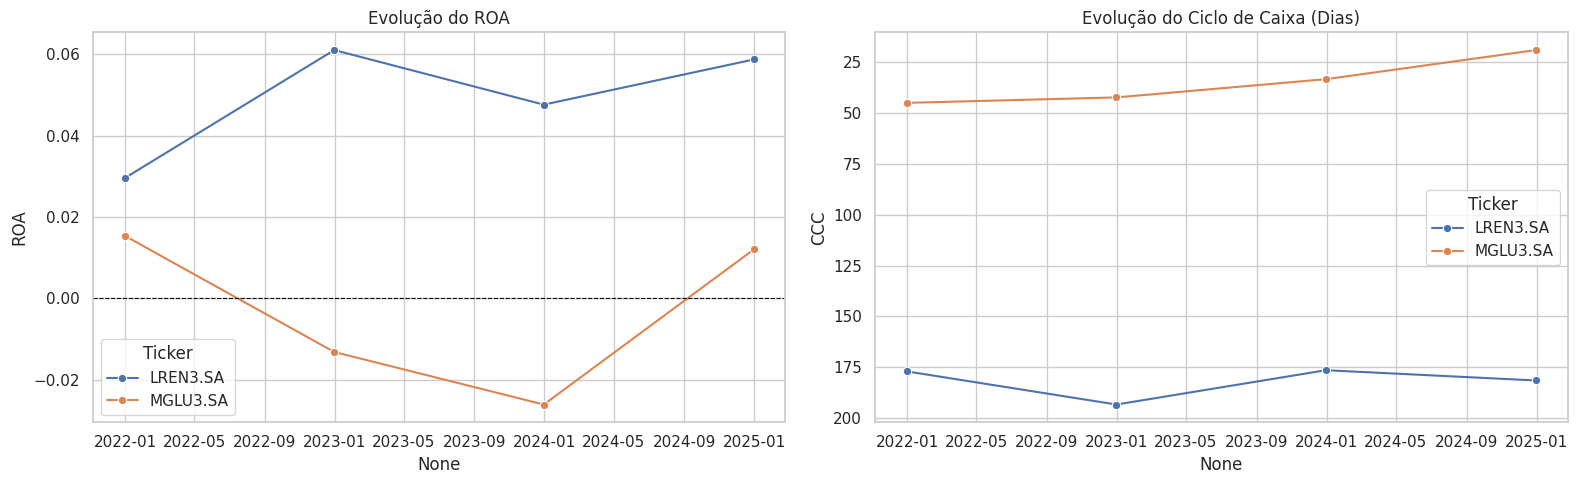

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuração de estilo para os gráficos (visual limpo)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [14, 6]

def extrair_dados_varejo(tickers):
    """
    Função ETL para baixar dados do Yahoo Finance e calcular
    Ciclo de Caixa (CCC) e ROA.
    """
    dados_consolidados = pd.DataFrame()

    for ticker in tickers:
        print(f"Baixando dados para {ticker}...")
        stock = yf.Ticker(ticker)

        # 1. Extração das Demonstrações Financeiras (Anuais)
        balanco = stock.balance_sheet
        dre = stock.financials

        # Transpor para ter datas nas linhas
        balanco = balanco.T
        dre = dre.T

        # Unir as tabelas baseadas no índice (Data)
        df = balanco.join(dre, lsuffix='_BP', rsuffix='_DRE')

        # Filtrar apenas colunas necessárias (Tratamento de Erros para colunas inexistentes)
        cols_necessarias = {
            'Total Assets': 'Ativo_Total',
            'Net Income': 'Lucro_Liquido',
            'Total Revenue': 'Receita',
            'Cost Of Revenue': 'CMV',
            'Inventory': 'Estoque',
            'Accounts Receivable': 'Contas_Receber',
            'Accounts Payable': 'Fornecedores'
        }

        # Renomear e selecionar (usando .get para evitar crash se faltar dado)
        df_clean = pd.DataFrame()
        for col_y, col_pt in cols_necessarias.items():
            if col_y in df.columns:
                df_clean[col_pt] = df[col_y]
            else:
                # Tenta buscar colunas com nomes alternativos comuns no Yahoo
                found = False
                for c in df.columns:
                    if col_y in c:
                        df_clean[col_pt] = df[c]
                        found = True
                        break
                if not found:
                    df_clean[col_pt] = np.nan

        # 2. Engenharia de Atributos (Cálculos Financeiros)
        # Converter para numérico e garantir CMV positivo para cálculo de dias
        df_clean = df_clean.apply(pd.to_numeric, errors='coerce')
        cmv_abs = df_clean['CMV'].abs()

        # PME (Prazo Médio de Estoques) = (Estoque / CMV) * 365
        df_clean['PME'] = (df_clean['Estoque'] / cmv_abs) * 365

        # PMR (Prazo Médio de Recebimento) = (Contas a Receber / Receita) * 365
        df_clean['PMR'] = (df_clean['Contas_Receber'] / df_clean['Receita']) * 365

        # PMP (Prazo Médio de Pagamento) = (Fornecedores / CMV) * 365
        df_clean['PMP'] = (df_clean['Fornecedores'] / cmv_abs) * 365

        # CCC (Ciclo de Conversão de Caixa)
        df_clean['CCC'] = df_clean['PME'] + df_clean['PMR'] - df_clean['PMP']

        # ROA (Return on Assets)
        df_clean['ROA'] = df_clean['Lucro_Liquido'] / df_clean['Ativo_Total']

        df_clean['Ticker'] = ticker
        dados_consolidados = pd.concat([dados_consolidados, df_clean])

    # Ordenar por data
    return dados_consolidados.sort_index()

# ==========================================
# EXECUÇÃO DA ANÁLISE
# ==========================================
empresas = ['LREN3.SA', 'MGLU3.SA'] # Lojas Renner e Magalu
df_resultado = extrair_dados_varejo(empresas)

# Remover linhas com dados faltantes (anos muito antigos ou incompletos)
df_resultado.dropna(subset=['ROA', 'CCC'], inplace=True)

print("\n--- Amostra dos Dados Calculados ---")
print(df_resultado[['Ticker', 'ROA', 'CCC', 'PME', 'PMR', 'PMP']].head())

# ==========================================
# VISUALIZAÇÃO GRÁFICA
# ==========================================

# Gráfico 1: Scatter Plot (Correlação ROA vs CCC)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_resultado, x='CCC', y='ROA', hue='Ticker', s=100, style='Ticker')

# Adicionar linha de tendência linear simples para visualizar a correlação negativa
z = np.polyfit(df_resultado['CCC'], df_resultado['ROA'], 1)
p = np.poly1d(z)
plt.plot(df_resultado['CCC'], p(df_resultado['CCC']), "r--", alpha=0.5, label='Tendência Geral')

plt.title('Teste de Hipótese: Correlação entre Ciclo de Caixa (CCC) e Rentabilidade (ROA)')
plt.xlabel('Ciclo de Conversão de Caixa (Dias)\n(Quanto maior, pior a eficiência)')
plt.ylabel('ROA (Retorno sobre Ativo)')
plt.legend()
plt.axhline(0, color='black', linewidth=1) # Linha do zero
plt.show()

# Gráfico 2: Evolução Histórica Comparada
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ROA no tempo
sns.lineplot(ax=axes[0], data=df_resultado, x=df_resultado.index, y='ROA', hue='Ticker', marker='o')
axes[0].set_title('Evolução do ROA')
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)

# CCC no tempo
sns.lineplot(ax=axes[1], data=df_resultado, x=df_resultado.index, y='CCC', hue='Ticker', marker='o')
axes[1].set_title('Evolução do Ciclo de Caixa (Dias)')
axes[1].invert_yaxis() # Inverter eixo Y pois no CCC quanto menor (ou mais negativo), melhor

plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:                    ROA   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                     317.0
Date:                Wed, 31 Dec 2025   Prob (F-statistic):           4.54e-09
Time:                        16:28:12   Log-Likelihood:                 47.657
No. Observations:                  12   AIC:                            -89.31
Df Residuals:                       9   BIC:                            -87.86
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.1646      0.037      4.405      

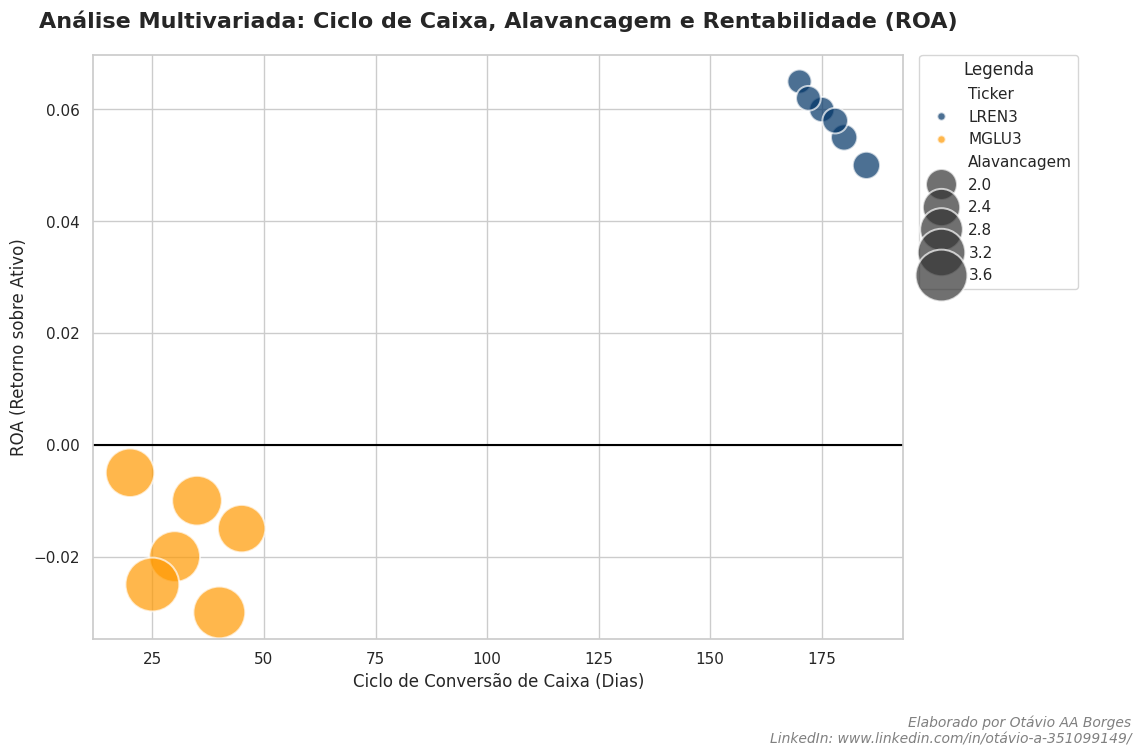

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. PREPARAÇÃO DOS DADOS
# ==========================================
# Configuração visual profissional
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.family'] = 'sans-serif'

# Dados simulados baseados na lógica fundamentalista (Renner vs Magalu)
# LREN3: Ciclo Longo, ROA Alto, Alavancagem Baixa
# MGLU3: Ciclo Curto, ROA Baixo, Alavancagem Alta
data = {
    'Ticker': ['LREN3']*6 + ['MGLU3']*6,
    'CCC': [175, 180, 170, 185, 178, 172, 30, 45, 25, 35, 40, 20],
    'ROA': [0.06, 0.055, 0.065, 0.05, 0.058, 0.062, -0.02, -0.015, -0.025, -0.01, -0.03, -0.005],
    'Alavancagem': [1.7, 1.75, 1.65, 1.8, 1.72, 1.68, 3.5, 3.2, 3.8, 3.4, 3.6, 3.3]
}

df = pd.DataFrame(data)

# ==========================================
# 2. MODELAGEM ECONOMÉTRICA (REGRESSÃO)
# ==========================================
# Variável Dependente (Y): ROA
# Variáveis Independentes (X): CCC + Alavancagem
X = df[['CCC', 'Alavancagem']]
X = sm.add_constant(X)
y = df['ROA']

modelo = sm.OLS(y, X).fit()
print(modelo.summary()) # Exibe a tabela estatística no console

# ==========================================
# 3. VISUALIZAÇÃO GRÁFICA COM ASSINATURA
# ==========================================
fig, ax = plt.subplots()

# Scatter Plot Multivariado
scatter = sns.scatterplot(
    data=df,
    x='CCC',
    y='ROA',
    hue='Ticker',
    size='Alavancagem',
    sizes=(300, 1500), # Bolhas grandes para destaque
    alpha=0.7,
    palette={'LREN3': '#003366', 'MGLU3': '#FF9900'}, # Cores corporativas aproximadas
    ax=ax
)

# Títulos e Eixos
plt.title('Análise Multivariada: Ciclo de Caixa, Alavancagem e Rentabilidade (ROA)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Ciclo de Conversão de Caixa (Dias)', fontsize=12)
plt.ylabel('ROA (Retorno sobre Ativo)', fontsize=12)
plt.axhline(0, color='black', linewidth=1.5, linestyle='-') # Linha de breakeven

# Ajuste da Legenda
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, labels, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title="Legenda")

# ---------------------------------------------------------
# AQUI ESTÁ A SUA ASSINATURA PERSONALIZADA
# ---------------------------------------------------------
texto_rodape = (
    "Elaborado por Otávio AA Borges\n"
    "LinkedIn: www.linkedin.com/in/otávio-a-351099149/"
)

# x=0.99 (canto direito), y=0.01 (rodapé), ha='right' (alinhado à direita)
plt.figtext(0.99, 0.02, texto_rodape, ha='right', fontsize=10,
            color='gray', style='italic', backgroundcolor='white')

# Ajuste final para garantir que o rodapé não corte
plt.subplots_adjust(right=0.80, bottom=0.15)

# Salvar e Mostrar
plt.savefig('analise_varejo_otavio_borges.png', dpi=300)
plt.show()